In [13]:
from google.colab import files
files.upload()  # yahan kaggle.json upload karo

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"adarshgupta07","key":"66aa9f71b90b76b2cbcb8e460f52fa00"}'}

In [14]:
print("Please run the cell with ID gDKWCyXLh0uU to upload your kaggle.json file.")

Please run the cell with ID gDKWCyXLh0uU to upload your kaggle.json file.


In [15]:
import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 600)

In [16]:
!pip install kaggle

In [17]:
!kaggle competitions download -c titanic

100% 34.1k/34.1k [00:00<00:00, 5.74MB/s]



In [18]:
import zipfile
with zipfile.ZipFile('titanic.zip', 'r') as zip_ref:
    zip_ref.extractall('titanic_data')

In [19]:
import pandas as pd
df = pd.read_csv('titanic_data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
print("Rows aur Columns:", df.shape)
print("\nColumn names:", df.columns.tolist())

Rows aur Columns: (891, 12)

Column names: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [22]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


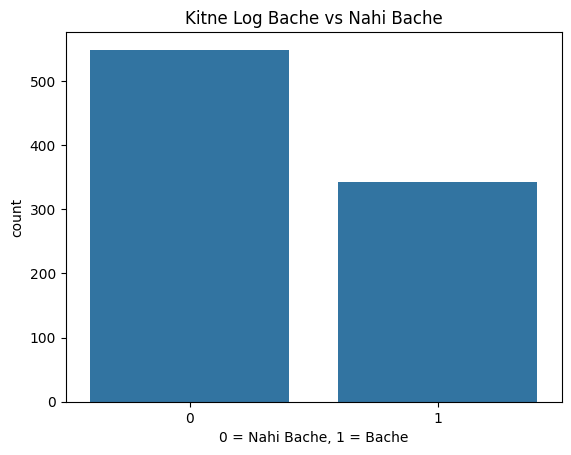

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Survived', data=df)
plt.title('Kitne Log Bache vs Nahi Bache')
plt.xlabel('0 = Nahi Bache, 1 = Bache')
plt.show()

In [26]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
print("age is missing ",df['Age'].isnull().sum())

age is missing  0


In [27]:
df.drop(columns=['Cabin'], inplace=True)
print("Cabin column hata di!")

Cabin column hata di!


In [28]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
print("Embarked missing values ab:", df['Embarked'].isnull().sum())

Embarked missing values ab: 0


/tmp/ipykernel_635/3272518382.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [29]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


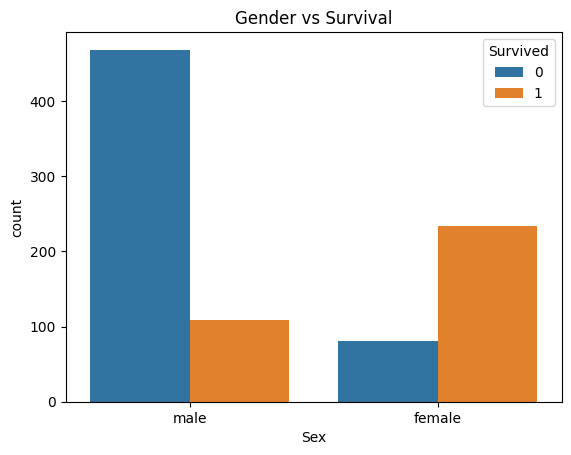

In [30]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Gender vs Survival')
plt.show()

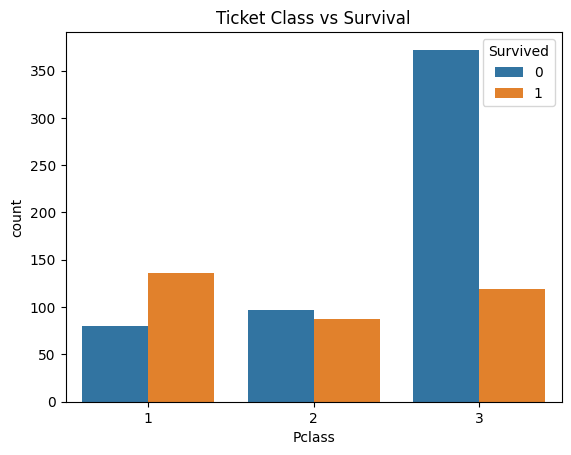

In [31]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Ticket Class vs Survival')
plt.show()

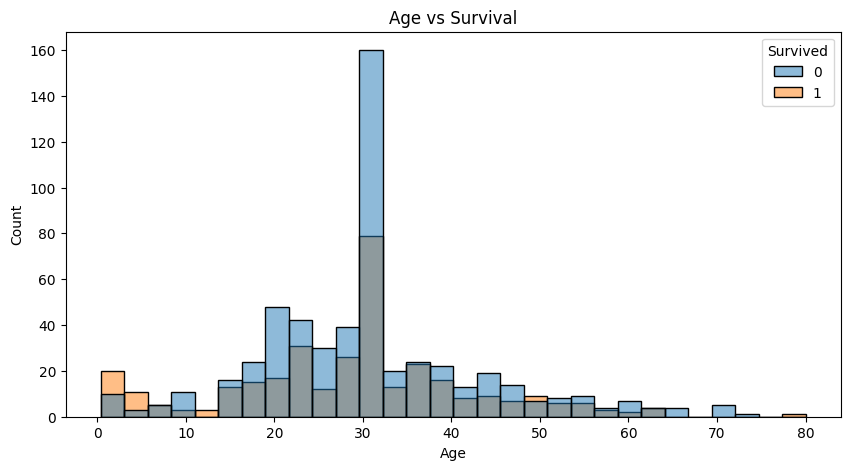

In [32]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Age', hue='Survived', bins=30)
plt.title('Age vs Survival')
plt.show()

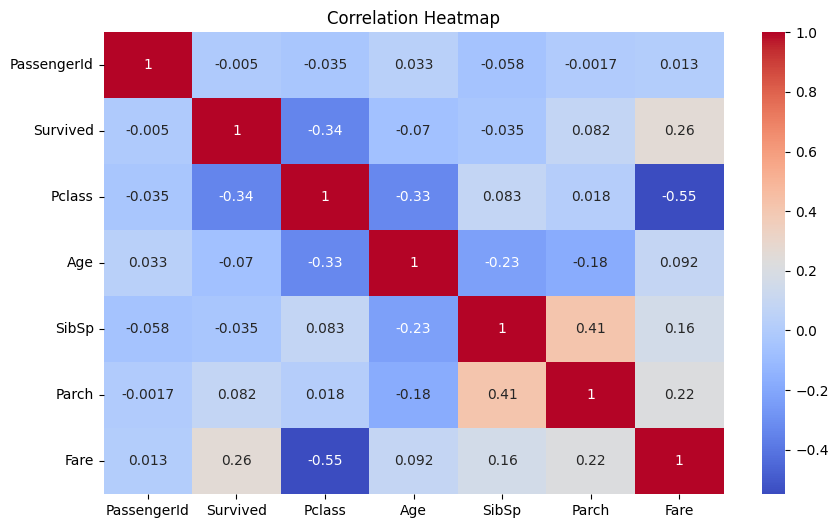

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [34]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.033207,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500
Age,0.033207,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566
SibSp,-0.057527,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000


In [36]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
print(df['Sex'].value_counts())

Sex
0    577
1    314
Name: count, dtype: int64


In [37]:
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
print(df['Embarked'].value_counts())

Embarked
0    646
1    168
2     77
Name: count, dtype: int64


In [38]:
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [39]:
print(df.shape)
df.isnull().sum()

(891, 8)


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [40]:
X = df.drop(columns=['Survived'])  # input — sab columns except Survived
y = df['Survived']                  # output — sirf Survived column

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 7)
y shape: (891,)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 7)
Testing data: (179, 7)


In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

print("Model train ho gaya!")

Model train ho gaya!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Model ki Accuracy:", accuracy * 100, "%")

Model ki Accuracy: 79.88826815642457 %


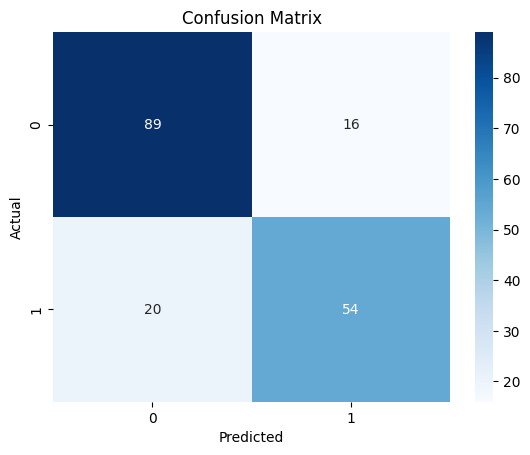

In [44]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

